# Классификация кошек и собак с использованием классических методов компьютерного зрения

## Цель работы
Разработать систему классификации изображений кошек и собак, используя классические методы компьютерного зрения:
- HOG (Histogram of Oriented Gradients)
- Цветовые гистограммы
- Текстуры (LBP, статистики GLCM)
- Комбинирование признаков
- ML классификаторы (SVM, Random Forest)

## Методология
Комбинирование нескольких классических методов извлечения признаков для повышения точности классификации.


## 1. Установка и импорт библиотек


In [ ]:
# %pip install opencv-python scikit-image scikit-learn matplotlib numpy pandas tqdm -qqq

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from skimage import feature, color, exposure
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

Библиотеки успешно импортированы!


### 2.1 Подготовка датасета Kaggle (Dogs vs Cats)
- Распакуем `train.zip` и `test1.zip`, расположенные в `dogs-vs-cats/`.
- Разложим изображения по папкам `cats/` и `dogs/` для удобной загрузки.
- При необходимости ограничим количество изображений для быстрой отладки.


In [ ]:
import zipfile

BASE_DIR = Path().resolve()
DATASET_DIR = BASE_DIR / "dogs-vs-cats"
RAW_TRAIN_ZIP = DATASET_DIR / "train.zip"
RAW_TEST_ZIP = DATASET_DIR / "test1.zip"
EXTRACT_DIR = DATASET_DIR / "extracted"
TRAIN_RAW_DIR = EXTRACT_DIR / "train_raw"
TRAIN_DIR = EXTRACT_DIR / "train"
CATS_FOLDER = TRAIN_DIR / "cats"
DOGS_FOLDER = TRAIN_DIR / "dogs"
TEST_DIR = EXTRACT_DIR / "test1"

MAX_TRAIN_PER_CLASS = 1200  # можно увеличить при достаточных ресурсах
RANDOM_STATE = 42

print("Рабочая директория:", BASE_DIR)
print("Путь к train.zip:", RAW_TRAIN_ZIP)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if RAW_TRAIN_ZIP.exists() and not TRAIN_RAW_DIR.exists():
    print("Распаковываем train.zip ...")
    with zipfile.ZipFile(RAW_TRAIN_ZIP, 'r') as zip_ref:
        zip_ref.extractall(TRAIN_RAW_DIR)
    print("train.zip распакован в", TRAIN_RAW_DIR)
elif TRAIN_RAW_DIR.exists():
    print("train_raw уже существует, пропускаем распаковку")
else:
    print("train.zip не найден, проверьте путь")

# Распаковка test1.zip (необязательно для обучения)
if RAW_TEST_ZIP.exists() and not TEST_DIR.exists():
    print("Распаковываем test1.zip ...")
    with zipfile.ZipFile(RAW_TEST_ZIP, 'r') as zip_ref:
        zip_ref.extractall(TEST_DIR)
    print("test1.zip распакован в", TEST_DIR)
elif TEST_DIR.exists():
    print("test1 уже существует, пропускаем распаковку")
else:
    print("test1.zip не найден (не критично для обучения)")

if TRAIN_RAW_DIR.exists():
    CATS_FOLDER.mkdir(parents=True, exist_ok=True)
    DOGS_FOLDER.mkdir(parents=True, exist_ok=True)
    moved_cats = 0
    moved_dogs = 0
    raw_files = list(TRAIN_RAW_DIR.rglob('*.jpg'))
    if len(raw_files) == 0:
        print(f"В {TRAIN_RAW_DIR} нет jpg-файлов. Проверьте распаковку train.zip.")
    for img_path in tqdm(raw_files, desc="Классификация файлов"):
        name = img_path.name.lower()
        if name.startswith('cat'):
            target = CATS_FOLDER / img_path.name
            moved_cats += 1
        elif name.startswith('dog'):
            target = DOGS_FOLDER / img_path.name
            moved_dogs += 1
        else:
            continue
        if not target.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            img_path.rename(target)
    print(f"Разложено: cats={moved_cats}, dogs={moved_dogs}")
else:
    print("TRAIN_RAW_DIR не найден, не удалось разложить изображения")


Рабочая директория: /Users/23108022/Documents/repositories/mephi-computer-vision-2025/bdz/solve
Путь к train.zip: /Users/23108022/Documents/repositories/mephi-computer-vision-2025/bdz/solve/dogs-vs-cats/train.zip
train_raw уже существует, пропускаем распаковку
test1 уже существует, пропускаем распаковку


Классификация файлов: 100%|██████████| 25000/25000 [00:03<00:00, 7252.33it/s]

Разложено: cats=12500, dogs=12500


## 2. Загрузка и подготовка данных

Для демонстрации будем использовать датасет кошек и собак. Если у вас есть свой датасет, укажите путь к папкам с изображениями.


In [ ]:
def load_images_from_folder(folder_path: Path, label: int, max_images: int | None = None):
    images: list[np.ndarray] = []
    labels: list[int] = []
    folder = Path(folder_path)
    
    if not folder.exists():
        print(f"Папка {folder_path} не найдена.")
        return images, labels
    
    image_files = sorted(folder.glob('*.jpg'))
    if max_images:
        image_files = image_files[:max_images]
    
    print(f"Найдено {len(image_files)} изображений в {folder_path}")
    
    for img_path in tqdm(image_files, desc=f"Загрузка {folder.name}"):
        try:
            img = cv2.imread(str(img_path))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(label)
        except Exception as e:
            print(f"Ошибка при загрузке {img_path}: {e}")
    
    return images, labels

# Если данных нет, код будет работать в демонстрационном режиме
cats_images, cats_labels = load_images_from_folder(CATS_FOLDER, label=0, max_images=MAX_TRAIN_PER_CLASS)
dogs_images, dogs_labels = load_images_from_folder(DOGS_FOLDER, label=1, max_images=MAX_TRAIN_PER_CLASS)

all_images = cats_images + dogs_images
all_labels = np.array(cats_labels + dogs_labels)

print(f"\nВсего загружено изображений: {len(all_images)}")
print(f"Кошек: {int(np.sum(all_labels == 0))}")
print(f"Собак: {int(np.sum(all_labels == 1))}")

if len(all_images) == 0:
    print("\n" + "="*60)
    print("Данные не найдены.")
    print("Поместите изображения в папки:")
    print(f"  - {CATS_FOLDER}/")
    print(f"  - {DOGS_FOLDER}/")
    print("И перезапустите ноутбук.")
    print("="*60)

Найдено 1200 изображений в /Users/23108022/Documents/repositories/mephi-computer-vision-2025/bdz/solve/dogs-vs-cats/extracted/train/cats


Загрузка cats: 100%|██████████| 1200/1200 [00:00<00:00, 1281.54it/s]


Найдено 1200 изображений в /Users/23108022/Documents/repositories/mephi-computer-vision-2025/bdz/solve/dogs-vs-cats/extracted/train/dogs


Загрузка dogs: 100%|██████████| 1200/1200 [00:00<00:00, 1394.12it/s]


Всего загружено изображений: 2400
Кошек: 1200
Собак: 1200


## 3. Извлечение признаков

Реализуем несколько классических методов извлечения признаков:
1. **HOG (Histogram of Oriented Gradients)** - для описания формы и структуры
2. **Цветовые гистограммы** - для описания цветового распределения
3. **LBP (Local Binary Pattern)** - для описания текстуры
4. **GLCM статистики** - для описания текстурных свойств


In [ ]:
def extract_hog_features(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), 
                         orientations=9, visualize=False):
    if len(image.shape) == 3:
        gray = color.rgb2gray(image)
    else:
        gray = image
    
    gray = cv2.resize(gray, (128, 128))
    
    hog_features = feature.hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=visualize,
        feature_vector=True
    )
    
    if visualize:
        return hog_features[0], hog_features[1]
    return hog_features

def extract_color_histogram(image, bins=32):
    image = cv2.resize(image, (128, 128))
    
    hist_r = cv2.calcHist([image], [0], None, [bins], [0, 256])
    hist_g = cv2.calcHist([image], [1], None, [bins], [0, 256])
    hist_b = cv2.calcHist([image], [2], None, [bins], [0, 256])
    
    hist_r = hist_r / (hist_r.sum() + 1e-7)
    hist_g = hist_g / (hist_g.sum() + 1e-7)
    hist_b = hist_b / (hist_b.sum() + 1e-7)
    
    features = np.concatenate([hist_r.flatten(), hist_g.flatten(), hist_b.flatten()])
    
    return features

def extract_lbp_features(image, num_points=24, radius=3):
    if len(image.shape) == 3:
        gray = color.rgb2gray(image)
    else:
        gray = image
    
    gray = cv2.resize(gray, (128, 128))
    gray = (gray * 255).astype(np.uint8)
    
    lbp = local_binary_pattern(gray, num_points, radius, method='uniform')
    
    n_bins = num_points + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(float)
    hist /= (hist.sum() + 1e-7)  # Нормализация
    
    return hist

def extract_glcm_features(image):
    if len(image.shape) == 3:
        gray = color.rgb2gray(image)
    else:
        gray = image
    
    gray = cv2.resize(gray, (128, 128))
    gray = (gray * 255).astype(np.uint8)
    
    gray_quantized = (gray / 32).astype(np.uint8)
    
    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    
    features = []
    for distance in distances:
        for angle in angles:
            glcm = graycomatrix(gray_quantized, [distance], [angle], 
                               levels=8, symmetric=True, normed=True)
            
            contrast = graycoprops(glcm, 'contrast')[0, 0]
            dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
            homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
            energy = graycoprops(glcm, 'energy')[0, 0]
            correlation = graycoprops(glcm, 'correlation')[0, 0]
            
            features.extend([contrast, dissimilarity, homogeneity, energy, correlation])
    
    return np.array(features)

def extract_all_features(image):
    hog_feat = extract_hog_features(image)
    color_feat = extract_color_histogram(image)
    lbp_feat = extract_lbp_features(image)
    glcm_feat = extract_glcm_features(image)
    
    all_features = np.concatenate([hog_feat, color_feat, lbp_feat, glcm_feat])
    
    return all_features

Функции извлечения признаков определены!


## 6. Обучение и оценка моделей
Обучим несколько классификаторов на объединённых признаках и сравним точность.


In [ ]:
X_train_scaled = X_test_scaled = None
y_train = y_test = None
scaler = None

if len(all_images) > 0:
    print("Извлечение признаков из изображений...")
    features_list: list[np.ndarray] = []
    
    for img in tqdm(all_images, desc="Извлечение признаков"):
        try:
            feat = extract_all_features(img)
            features_list.append(feat)
        except Exception as e:
            print(f"Ошибка при извлечении признаков: {e}")
            features_list.append(np.zeros(1000))  # Примерный размер
    
    X: np.ndarray = np.asarray(features_list)
    y: np.ndarray = np.asarray(all_labels)
    
    print(f"\nФорма матрицы признаков: {X.shape}")
    print(f"Размерность признаков: {X.shape[1]}")
    print(f"Количество образцов: {X.shape[0]}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    X_train = np.asarray(X_train)
    X_test = np.asarray(X_test)
    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)
    
    print(f"\nОбучающая выборка: {X_train.shape[0]} образцов")
    print(f"Тестовая выборка: {X_test.shape[0]} образцов")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
else:
    print("Нет данных для обработки. Пожалуйста, загрузите изображения.")


Извлечение признаков из изображений...


Извлечение признаков: 100%|██████████| 2400/2400 [00:11<00:00, 201.97it/s]



Форма матрицы признаков: (2400, 8242)
Размерность признаков: 8242
Количество образцов: 2400

Обучающая выборка: 1920 образцов
Тестовая выборка: 480 образцов
Признаки нормализованы!


## 5. Обучение классификаторов

Используем два классификатора:
1. **SVM (Support Vector Machine)** - линейный и RBF
2. **Random Forest** - ансамблевый метод


In [ ]:
def train_and_evaluate():
    if X_train_scaled is None or X_test_scaled is None:
        print("Нет данных для обучения. Выполните предыдущие ячейки.")
        return None
    print("Начинаем обучение моделей...")
    models = {
        "SVM (linear)": SVC(kernel="linear", C=1.0, probability=True, random_state=RANDOM_STATE),
        "SVM (RBF)": SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1),
    }
    results = {}
    for name, model in models.items():
        print(f"\n=== {name} ===")
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        print(f"Accuracy: {acc:.4f}")
        print(classification_report(y_test, preds, target_names=["cat", "dog"]))
        results[name] = {
            "model": model,
            "preds": preds,
            "acc": acc,
        }
    return results

results = train_and_evaluate()


Начинаем обучение моделей...

=== SVM (linear) ===
Accuracy: 0.6687
              precision    recall  f1-score   support

         cat       0.68      0.63      0.66       240
         dog       0.66      0.71      0.68       240

    accuracy                           0.67       480
   macro avg       0.67      0.67      0.67       480
weighted avg       0.67      0.67      0.67       480


=== SVM (RBF) ===
Accuracy: 0.7208
              precision    recall  f1-score   support

         cat       0.72      0.72      0.72       240
         dog       0.72      0.72      0.72       240

    accuracy                           0.72       480
   macro avg       0.72      0.72      0.72       480
weighted avg       0.72      0.72      0.72       480


=== RandomForest ===
Accuracy: 0.7333
              precision    recall  f1-score   support

         cat       0.71      0.79      0.75       240
         dog       0.76      0.68      0.72       240

    accuracy                           

Лучшая модель: RandomForest (accuracy=0.7333)


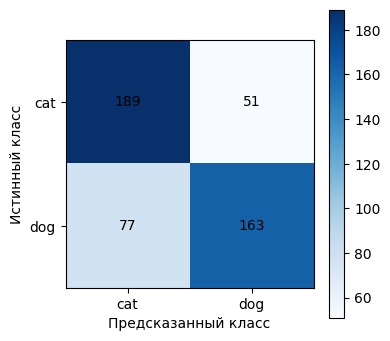

In [ ]:
results = results or {}

if len(results) > 0:
    # Выберем лучшую модель по accuracy
    best_name = max(results, key=lambda k: results[k]["acc"])
    best = results[best_name]
    print(f"Лучшая модель: {best_name} (accuracy={best['acc']:.4f})")
    cm = confusion_matrix(y_test, best["preds"])
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["cat", "dog"]); ax.set_yticklabels(["cat", "dog"])
    ax.set_xlabel("Предсказанный класс"); ax.set_ylabel("Истинный класс")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax)
    plt.show()
else:
    print("Результаты отсутствуют. Запустите обучение.")
